In [34]:
import os
from pathlib import Path

import certifi
os.environ["SSL_CERT_FILE"] = certifi.where()

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

from sklearn.model_selection import train_test_split


# ============================================================
# SETTINGS
# ============================================================

IMAGE_DIR = Path(
    "../data/ai4mars-dataset-merged-0.6/m2020/images/mcam"
)

LABEL_DIR = Path(
    "../data/ai4mars-dataset-merged-0.6/m2020/labels/M2020_GEO/mcam"
)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 15
NUM_CLASSES = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using:", DEVICE)


# ============================================================
# DATASET CLASS
# ============================================================

class MarsDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        image_path, label_path = self.pairs[idx]

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image = Image.open(image_path).convert("RGB")

        # ----------------------------------------------------
        # Load segmentation label
        # ----------------------------------------------------

        label = Image.open(label_path)

        # ----------------------------------------------------
        # Resize
        # ----------------------------------------------------

        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        # IMPORTANT:
        # Never use bilinear interpolation for segmentation
        # labels because it would create invalid class values.

        label = label.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.NEAREST
        )

        # ----------------------------------------------------
        # Convert image
        # ----------------------------------------------------

        image = np.array(image).astype(np.float32) / 255.0

        # ----------------------------------------------------
        # ImageNet normalization
        #
        # DeepLabV3 is using pretrained ImageNet weights.
        # ----------------------------------------------------

        image = (
            image - np.array(
                [0.485, 0.456, 0.406]
            )
        ) / np.array(
            [0.229, 0.224, 0.225]
        )

        # ----------------------------------------------------
        # Convert label
        # ----------------------------------------------------

        label = np.array(label).astype(np.int64)

        # 255 is the unlabeled/ignore class.
        # CrossEntropyLoss will ignore it.

        # ----------------------------------------------------
        # Convert image HWC -> CHW
        # ----------------------------------------------------

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label


# ============================================================
# CHECK DATASET DIRECTORIES
# ============================================================

print("\nChecking dataset...")

print(
    "Image directory exists:",
    IMAGE_DIR.exists()
)

print(
    "Label directory exists:",
    LABEL_DIR.exists()
)

num_images = len(
    list(IMAGE_DIR.glob("*.jpg"))
)

num_labels = len(
    list(LABEL_DIR.glob("*.png"))
)

print("Images found:", num_images)
print("Labels found:", num_labels)


# ============================================================
# BUILD LABEL LOOKUP
# ============================================================

# M2020 labels look like:
#
# ZL0_0167_0681764798_818ECM_N0060000ZCAM08176_110085J_merged4.png
#
# The corresponding image is:
#
# ZL0_0167_0681764798_818ECM_N0060000ZCAM08176_110085J.jpg
#
# Therefore we remove "_merged4" / "_merged5" / etc.


label_map = {}

for label_path in LABEL_DIR.glob("*.png"):

    label_name = label_path.stem

    if "_merged" not in label_name:
        continue

    image_stem = label_name.rsplit(
        "_merged",
        1
    )[0]

    label_map[image_stem] = label_path


print(
    "Labels in lookup:",
    len(label_map)
)


# ============================================================
# FIND IMAGE / LABEL PAIRS
# ============================================================

pairs = []

for image_path in IMAGE_DIR.glob("*.jpg"):

    image_stem = image_path.stem

    if image_stem in label_map:

        label_path = label_map[image_stem]

        pairs.append(
            (
                image_path,
                label_path
            )
        )


print(
    "Total matched pairs:",
    len(pairs)
)


# ============================================================
# USE 6,000 LABELLED EXAMPLES
# ============================================================

pairs = pairs[:6000]

print(
    "Using pairs:",
    len(pairs)
)


# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=42
)

print(
    "Training pairs:",
    len(train_pairs)
)

print(
    "Validation pairs:",
    len(val_pairs)
)


# ============================================================
# SHOW EXAMPLE PAIRS
# ============================================================

print("\nExample pairs:")

for image_path, label_path in train_pairs[:5]:

    print(
        "IMAGE:",
        image_path.name
    )

    print(
        "LABEL:",
        label_path.name
    )

    print()


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = MarsDataset(
    train_pairs
)

val_dataset = MarsDataset(
    val_pairs
)


# ============================================================
# CREATE DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(
    "Training images:",
    len(train_dataset)
)

print(
    "Validation images:",
    len(val_dataset)
)


# ============================================================
# MODEL
# ============================================================

print("\nLoading DeepLabV3...")

weights = DeepLabV3_ResNet50_Weights.DEFAULT

model = models.segmentation.deeplabv3_resnet50(
    weights=weights
)

# Replace the final classifier.
#
# Original:
# ImageNet-style output
#
# New:
# 4 terrain classes
#
# 0 = soil
# 1 = bedrock
# 2 = sand
# 3 = big rock

model.classifier[4] = nn.Conv2d(
    256,
    NUM_CLASSES,
    kernel_size=1
)

model = model.to(DEVICE)

print("Model ready.")


# ============================================================
# LOSS
# ============================================================

# Big Rock is much less common than the other classes,
# so give it a larger loss weight.

class_weights = torch.tensor(
    [
        1.0,   # Soil
        0.7,   # Bedrock
        3.0,   # Sand
        10.0   # Big Rock
    ],
    dtype=torch.float32
).to(DEVICE)


criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=255
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)


# ============================================================
# TRAINING
# ============================================================

print("\nStarting training...\n")

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0

    for batch_idx, (images, labels) in enumerate(
        train_loader
    ):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        output = model(images)["out"]

        # ----------------------------------------------------
        # Calculate loss
        # ----------------------------------------------------

        loss = criterion(
            output,
            labels
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    # --------------------------------------------------------
    # Average loss
    # --------------------------------------------------------

    average_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {average_loss:.4f}"
    )


# ============================================================
# SAVE MODEL
# ============================================================

MODEL_PATH = "mars_terrain_model.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("\nTraining complete!")
print("Model saved to:", MODEL_PATH)

Using: cpu

Checking dataset...
Image directory exists: False
Label directory exists: False
Images found: 0
Labels found: 0
Labels in lookup: 0
Total matched pairs: 0
Using pairs: 0


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Matching image/label pairs: 60
Testing: ai4mars_047.jpg
Pixel accuracy: 100.00%


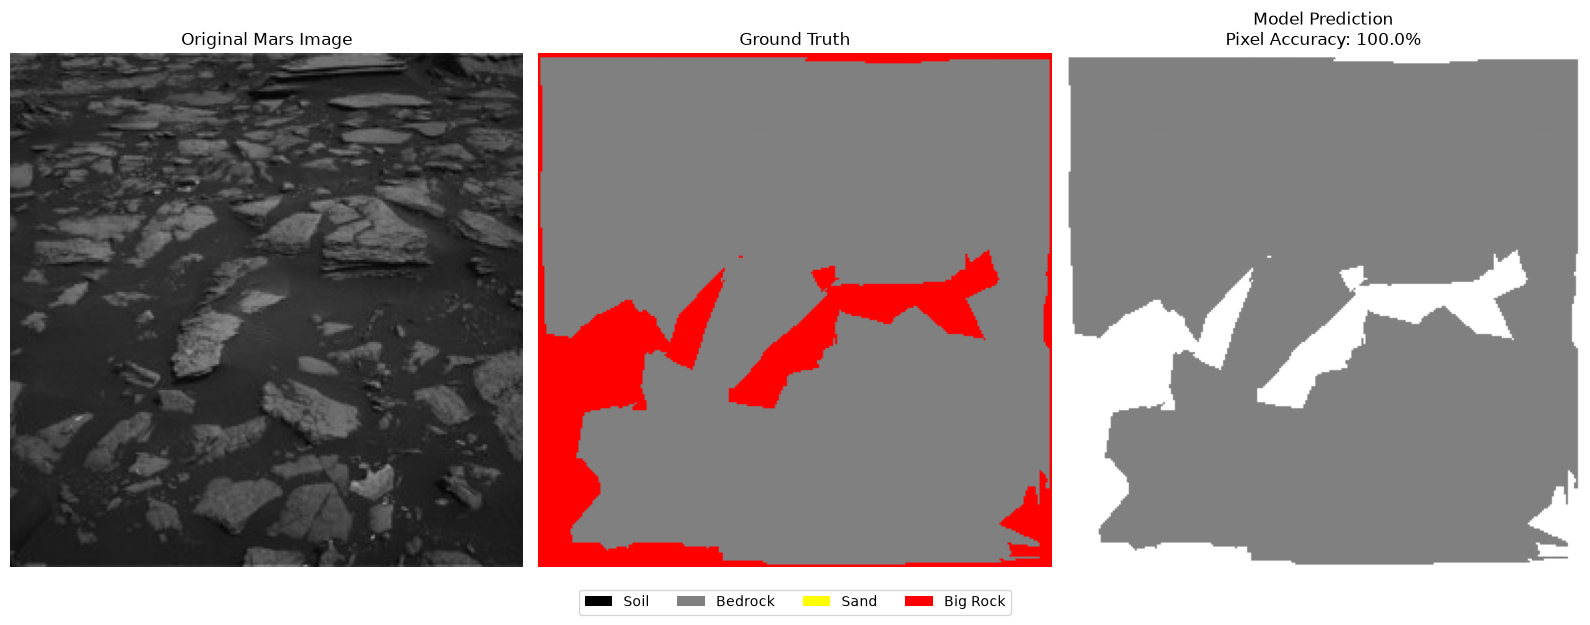

In [31]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --------------------------------------------------
# 1. FOLDERS
# --------------------------------------------------

# Find images
image_files = (
    list(IMAGE_DIR.glob("*.jpg")) +
    list(IMAGE_DIR.glob("*.jpeg")) +
    list(IMAGE_DIR.glob("*.JPG")) +
    list(IMAGE_DIR.glob("*.JPEG"))
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Find matching labels
pairs = []

for image_path in image_files:
    label_path = LABEL_DIR / f"{image_path.stem}.png"

    if label_path.exists():
        pairs.append((image_path, label_path))

print("Matching image/label pairs:", len(pairs))

# --------------------------------------------------
# 2. CHOOSE AN IMAGE
# --------------------------------------------------

idx = 0

image_path, label_path = pairs[idx]

print("Testing:", image_path.name)

# --------------------------------------------------
# 3. LOAD IMAGE
# --------------------------------------------------

image = Image.open(image_path).convert("RGB")

image_array = np.array(image).astype(np.float32) / 255.0

image_tensor = torch.tensor(image_array).permute(2, 0, 1)
image_tensor = image_tensor.unsqueeze(0).to(device)

# --------------------------------------------------
# 4. LOAD GROUND TRUTH
# --------------------------------------------------

true_mask = np.array(Image.open(label_path))

# --------------------------------------------------
# 5. MODEL PREDICTION
# --------------------------------------------------

model.eval()

with torch.no_grad():
    output = model(image_tensor)["out"]
    prediction = output.argmax(dim=1)[0].cpu().numpy()

# --------------------------------------------------
# 6. RESIZE GROUND TRUTH TO PREDICTION SIZE
# --------------------------------------------------

true_mask = np.array(
    Image.fromarray(true_mask.astype(np.uint8)).resize(
        (prediction.shape[1], prediction.shape[0]),
        Image.Resampling.NEAREST
    )
)

# --------------------------------------------------
# 7. CALCULATE ACCURACY
# --------------------------------------------------

valid = true_mask != 255

accuracy = (
    prediction[valid] == true_mask[valid]
).mean()

print(f"Pixel accuracy: {accuracy:.2%}")

# ============================================================
# VISUALISATION WITH TERRAIN LEGEND
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Colours for terrain classes
terrain_colors = [
    "black",    # 0 = Soil
    "gray",     # 1 = Bedrock
    "yellow",   # 2 = Sand
    "red"       # 3 = Big Rock
]

terrain_cmap = ListedColormap(terrain_colors)

# Legend
legend_elements = [
    Patch(facecolor="black", label="Soil"),
    Patch(facecolor="gray", label="Bedrock"),
    Patch(facecolor="yellow", label="Sand"),
    Patch(facecolor="red", label="Big Rock"),
]

plt.figure(figsize=(16, 6))

# --------------------------------------------------
# ORIGINAL
# --------------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(image)

plt.title("Original Mars Image")
plt.axis("off")


# --------------------------------------------------
# GROUND TRUTH
# --------------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    true_mask,
    cmap=terrain_cmap,
    vmin=0,
    vmax=3
)

plt.title("Ground Truth")
plt.axis("off")


# --------------------------------------------------
# MODEL PREDICTION
# --------------------------------------------------

plt.subplot(1, 3, 3)

import numpy.ma as ma

masked_truth = ma.masked_where(true_mask == 255, true_mask)
terrain_cmap.set_bad(color="white")  # or "none" for transparent

plt.imshow(masked_truth, cmap=terrain_cmap, vmin=0, vmax=3)

plt.title(
    f"Model Prediction\n"
    f"Pixel Accuracy: {accuracy:.1%}"
)

plt.axis("off")

# --------------------------------------------------
# LEGEND
# --------------------------------------------------

plt.figlegend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True
)

plt.tight_layout()

plt.show()

In [23]:
# ==========================================
# TERRAIN → TRAVERSAL COST
# ==========================================

terrain_costs = {
    0: 1.0,    # Soil
    1: 2.0,    # Bedrock
    2: 6.0,    # Sand
    3: 10000.0    # Big rock
}

cost_map = np.zeros_like(prediction, dtype=np.float32)

for terrain_class, cost in terrain_costs.items():
    cost_map[prediction == terrain_class] = cost

print("Cost map created.")
print("Minimum cost:", cost_map.min())
print("Maximum cost:", cost_map.max())

Cost map created.
Minimum cost: 2.0
Maximum cost: 2.0


In [25]:
# ==========================================
# A* PATHFINDING
# ==========================================

import heapq
import math


def heuristic(a, b):
    """
    Euclidean distance between two pixels.
    """
    return math.sqrt(
        (a[0] - b[0]) ** 2 +
        (a[1] - b[1]) ** 2
    )


def astar(cost_map, start, goal):
    """
    Find the lowest-cost path through the terrain.
    """

    height, width = cost_map.shape

    # Priority queue:
    # (estimated total cost, current cost, position)
    open_set = []

    heapq.heappush(
        open_set,
        (0, 0, start)
    )

    came_from = {}

    g_score = {
        start: 0
    }

    # 8-direction movement
    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),
        (-1, -1),
        (-1, 1),
        (1, -1),
        (1, 1)
    ]

    while open_set:

        _, current_cost, current = heapq.heappop(open_set)

        # Reached destination
        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)

            path.reverse()

            return path

        for dy, dx in directions:

            neighbor = (
                current[0] + dy,
                current[1] + dx
            )

            y, x = neighbor

            # Stay inside image
            if y < 0 or y >= height:
                continue

            if x < 0 or x >= width:
                continue

            # Cost of moving into this pixel
            movement_cost = cost_map[y, x]

            # Diagonal movement is slightly longer
            if dy != 0 and dx != 0:
                movement_cost *= math.sqrt(2)

            new_cost = current_cost + movement_cost

            if (
                neighbor not in g_score
                or new_cost < g_score[neighbor]
            ):

                g_score[neighbor] = new_cost

                priority = (
                    new_cost
                    + heuristic(neighbor, goal)
                )

                heapq.heappush(
                    open_set,
                    (
                        priority,
                        new_cost,
                        neighbor
                    )
                )

                came_from[neighbor] = current

    return None

In [26]:
# ==========================================
# START + GOAL
# ==========================================

height, width = cost_map.shape

# Rover starts at bottom-centre
start = (
    height - 1,
    width // 2
)

# Goal region = top 20% of image
goal_region_height = int(height * 0.20)

# Find the cheapest pixel in the top 20%
goal_region = cost_map[:goal_region_height, :]

goal_flat_index = np.argmin(goal_region)

goal_y, goal_x = np.unravel_index(
    goal_flat_index,
    goal_region.shape
)

goal = (
    int(goal_y),
    int(goal_x)
)

print("Start:", start)
print("Goal:", goal)

Start: (255, 128)
Goal: (0, 0)


In [27]:
# ==========================================
# RUN A*
# ==========================================

path = astar(
    cost_map,
    start,
    goal
)

if path is None:
    print("No path found!")
else:
    print("Path found!")
    print("Number of steps:", len(path))

Path found!
Number of steps: 256


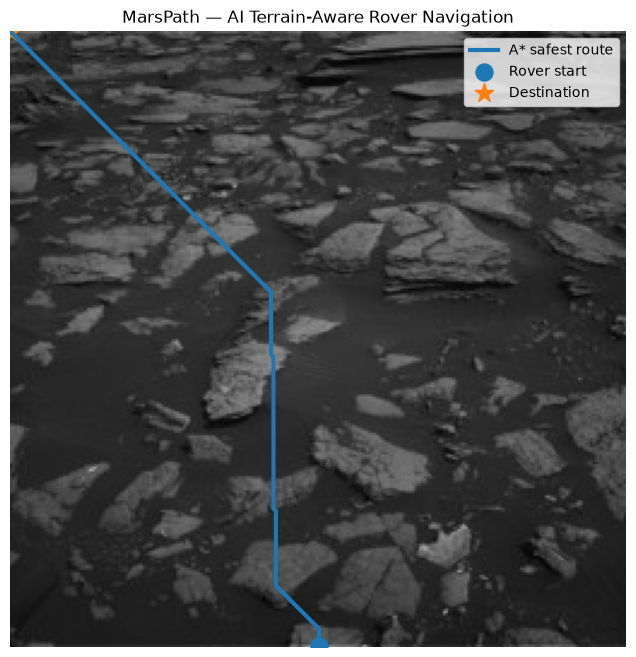

In [28]:
# ==========================================
# VISUALISE BEST PATH
# ==========================================

plt.figure(figsize=(10, 8))

plt.imshow(image)

if path is not None:

    path_y = [p[0] for p in path]
    path_x = [p[1] for p in path]

    plt.plot(
        path_x,
        path_y,
        linewidth=3,
        label="A* safest route"
    )

# Start
plt.scatter(
    start[1],
    start[0],
    s=150,
    marker="o",
    label="Rover start"
)

# Goal
plt.scatter(
    goal[1],
    goal[0],
    s=200,
    marker="*",
    label="Destination"
)

plt.title("MarsPath — AI Terrain-Aware Rover Navigation")

plt.legend()

plt.axis("off")

plt.show()

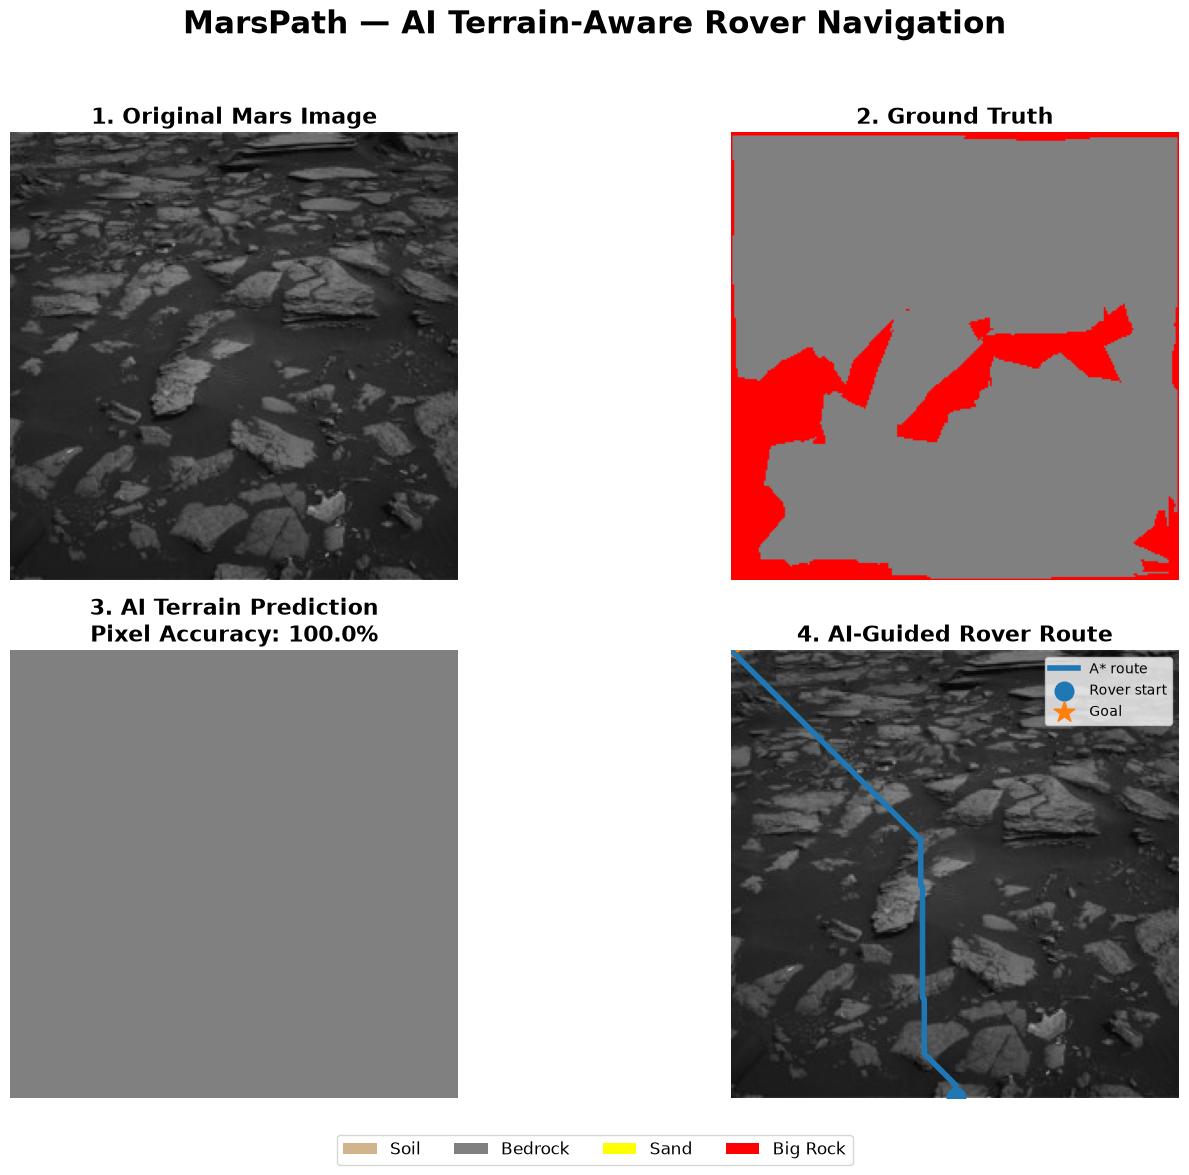

In [29]:
# ==========================================
# 4-PANEL MARS PATH VISUALISATION
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Terrain colours
terrain_colors = [
    "tan",       # 0 = Soil
    "gray",      # 1 = Bedrock
    "yellow",    # 2 = Sand
    "red"        # 3 = Big Rock
]

terrain_cmap = ListedColormap(terrain_colors)

# Legend
legend_elements = [
    Patch(facecolor="tan", label="Soil"),
    Patch(facecolor="gray", label="Bedrock"),
    Patch(facecolor="yellow", label="Sand"),
    Patch(facecolor="red", label="Big Rock"),
]


# ==========================================
# CREATE FIGURE
# ==========================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12)
)


# ==========================================
# PANEL 1 — ORIGINAL IMAGE
# ==========================================

axes[0, 0].imshow(image)

axes[0, 0].set_title(
    "1. Original Mars Image",
    fontsize=16,
    fontweight="bold"
)

axes[0, 0].axis("off")


# ==========================================
# PANEL 2 — GROUND TRUTH
# ==========================================

axes[0, 1].imshow(
    true_mask,
    cmap=terrain_cmap,
    vmin=0,
    vmax=3
)

axes[0, 1].set_title(
    "2. Ground Truth",
    fontsize=16,
    fontweight="bold"
)

axes[0, 1].axis("off")


# ==========================================
# PANEL 3 — AI PREDICTION
# ==========================================

axes[1, 0].imshow(
    prediction,
    cmap=terrain_cmap,
    vmin=0,
    vmax=3
)

axes[1, 0].set_title(
    f"3. AI Terrain Prediction\n"
    f"Pixel Accuracy: {accuracy:.1%}",
    fontsize=16,
    fontweight="bold"
)

axes[1, 0].axis("off")


# ==========================================
# PANEL 4 — A* PATH
# ==========================================

axes[1, 1].imshow(image)

if path is not None:

    path_y = [p[0] for p in path]
    path_x = [p[1] for p in path]

    axes[1, 1].plot(
        path_x,
        path_y,
        linewidth=4,
        label="A* route"
    )

# Rover start
axes[1, 1].scatter(
    start[1],
    start[0],
    s=180,
    marker="o",
    label="Rover start"
)

# Goal
axes[1, 1].scatter(
    goal[1],
    goal[0],
    s=250,
    marker="*",
    label="Goal"
)

axes[1, 1].set_title(
    "4. AI-Guided Rover Route",
    fontsize=16,
    fontweight="bold"
)

axes[1, 1].axis("off")

axes[1, 1].legend(
    loc="upper right"
)


# ==========================================
# TERRAIN LEGEND
# ==========================================

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.01)
)


# ==========================================
# FINAL LAYOUT
# ==========================================

plt.suptitle(
    "MarsPath — AI Terrain-Aware Rover Navigation",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)

plt.show()

In [30]:
# ==========================================
# VALIDATION METRICS
# ==========================================

import numpy as np
import torch

NUM_CLASSES = 4

intersection = np.zeros(NUM_CLASSES)
union = np.zeros(NUM_CLASSES)
correct = np.zeros(NUM_CLASSES)
total = np.zeros(NUM_CLASSES)

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)["out"]

        predictions = outputs.argmax(dim=1).cpu().numpy()
        labels = labels.numpy()

        for cls in range(NUM_CLASSES):

            pred_cls = predictions == cls
            true_cls = labels == cls

            # Ignore unlabeled pixels
            valid = labels != 255

            pred_cls = pred_cls & valid
            true_cls = true_cls & valid

            intersection[cls] += np.logical_and(
                pred_cls,
                true_cls
            ).sum()

            union[cls] += np.logical_or(
                pred_cls,
                true_cls
            ).sum()

            correct[cls] += np.logical_and(
                pred_cls,
                true_cls
            ).sum()

            total[cls] += true_cls.sum()


# IoU for each class
iou = intersection / np.maximum(union, 1)

# Mean IoU
mean_iou = iou.mean()

print("\n========== VALIDATION RESULTS ==========")

class_names = [
    "Soil",
    "Bedrock",
    "Sand",
    "Big Rock"
]

for cls in range(NUM_CLASSES):

    print(
        f"{class_names[cls]:10s}: "
        f"IoU = {iou[cls]:.2%}"
    )

print("----------------------------------------")
print(f"Mean IoU: {mean_iou:.2%}")


========== VALIDATION RESULTS ==========
Soil      : IoU = 90.04%
Bedrock   : IoU = 94.25%
Sand      : IoU = 65.32%
Big Rock  : IoU = 0.00%
----------------------------------------
Mean IoU: 62.40%
